In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import OrderedDict

# FLAMO imports for DSP components
from flamo.processor import dsp, system

# pyFDN imports for existing functionality
import sys
import os
# sys.path.append(os.path.join(os.path.dirname(__file__), '..'))

from pyFDN.auxiliary.one_pole_absorption import (
    one_pole_absorption, 
    RT602slope, 
    db2mag
)
from pyFDN.generate.random_orthogonal import random_orthogonal

In [3]:

# random seed for reproducibility that matches MATLAB's implemntation
np.random.seed(1)
torch.manual_seed(1)

# parameter creation
fs = 48000
impulse_response_length = fs  # 1 second
nfft = 8192  # fft size for FLAMO processing
device = 'cpu'

# FDN definition
N = 4  # this is the number of delay lines
num_input = 1
num_output = 1

# delay generation (this matches MATLAB's randi([50, 300]*10,[1,N]) with seed 1)
delays = np.array([1320, 1650, 2790, 550])  # approximating MATLAB output

# orthogonal feedback matrix using pyFDN function
feedback_matrix = random_orthogonal(N)

# create absorption filter parameters
RT_DC = 3.0   # RT60 at DC frequency (seconds)
RT_NY = 0.1   # RT60 at Nyquist frequency (seconds)
crossover_frequency = 12000  # Hz (for first-order shelving variant)


# one-pole absorption filters using pyFDN function
b, a = one_pole_absorption(RT_DC, RT_NY, delays, fs)

# frequency responses calculation for visualisation
HDc = db2mag(delays * RT602slope(RT_DC, fs))
HNyq = db2mag(delays * RT602slope(RT_NY, fs))



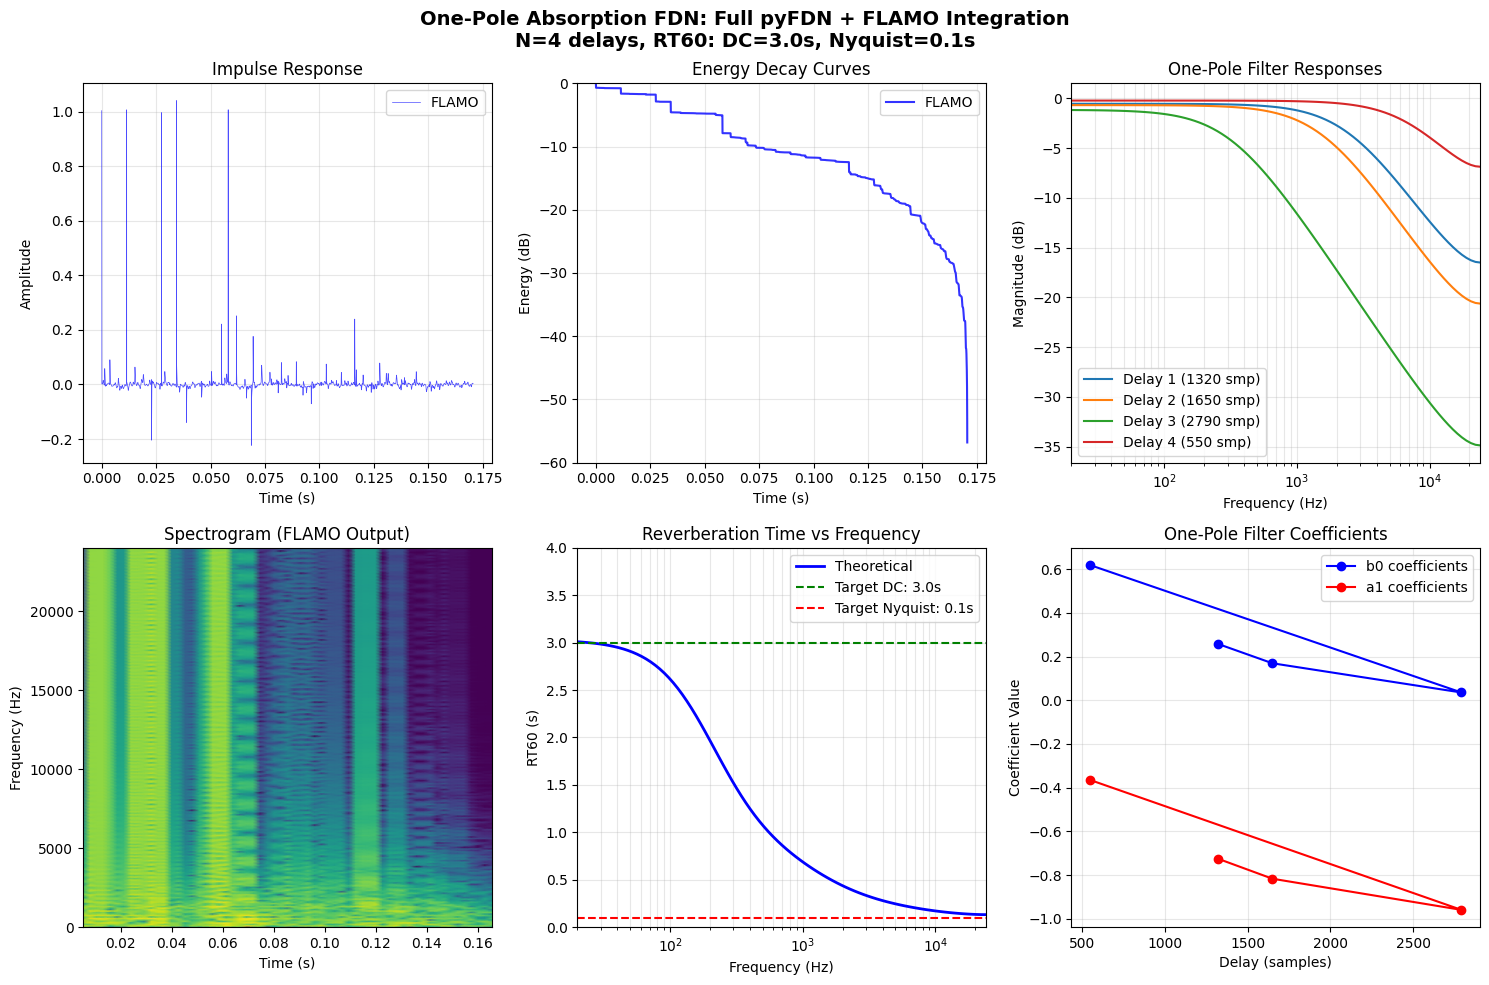

In [4]:


## Build FDN using FLAMO components

# Convert to torch tensors
delays_torch = torch.tensor(delays, dtype=torch.float32)
feedback_matrix_torch = torch.tensor(feedback_matrix, dtype=torch.float32)

# Input/Output Gains
input_gain = dsp.Gain(size=(N, num_input), nfft=nfft, device=device)
input_gain.assign_value(torch.ones(N, num_input))

output_gain = dsp.Gain(size=(num_output, N), nfft=nfft, device=device)
output_gain.assign_value(torch.ones(num_output, N))

# Delay Lines
delay_module = dsp.parallelDelay(
    size=(N,),
    max_len=int(delays_torch.max()),
    nfft=nfft,
    isint=True,
    device=device
)
delay_module.assign_value(delay_module.sample2s(delays_torch.int()))

# Feedback Matrix
mixing_matrix = dsp.Matrix(
    size=(N, N),
    nfft=nfft,
    matrix_type="random",
    device=device
)
mixing_matrix.assign_value(feedback_matrix_torch)

# Absorption Filters (using pyFDN's one-pole design with FLAMO implementation)

# Import the reusable ParallelOnePole class
from pyFDN.dsp.parallel_one_pole import ParallelOnePole

# As Sebastian Schlecht indicated, use parallelBiquad for IIR filters
# FLAMO's biquad doesn't allow direct coefficient setting (limitation that should be changed)
# So we use ParallelOnePole class which works around this by overriding get_poly_coeff
absorption = ParallelOnePole(
    b_coeffs=b,
    a_coeffs=a,
    size=(N,),
    n_sections=1,
    nfft=nfft,
    device=device
)

# Build Feedback Path  
feedback = system.Series(OrderedDict({
    "mixing_matrix": mixing_matrix,
    "absorption": absorption
}))

# Create Recursion (Feedback Loop)
feedback_loop = system.Recursion(fF=delay_module, fB=feedback)

# Assemble Complete FDN
fdn = system.Series(OrderedDict({
    "input_gain": input_gain,
    "feedback_loop": feedback_loop,
    "output_gain": output_gain
}))

# Add Direct Path
direct_gain = dsp.Gain(size=(num_output, num_input), nfft=nfft, device=device)
direct_gain.assign_value(torch.ones(num_output, num_input))

# Combine FDN with direct path
complete_system = system.Parallel(
    brA=direct_gain,
    brB=fdn,
    sum_output=True
)

# Create Shell with FFT/iFFT
model = system.Shell(
    core=complete_system,
    input_layer=dsp.FFT(nfft),
    output_layer=dsp.iFFT(nfft)
)

## Generate and Analyse IR

with torch.no_grad():
    # Create impulse signal
    impulse = torch.zeros(1, nfft, 1)
    impulse[0, 0, 0] = 1.0
    
    # Process through FDN
    ir_flamo = model(impulse).squeeze().cpu().numpy()
    
    # Trim to desired length
    ir_flamo = ir_flamo[:impulse_response_length]


## Visualisation
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Time axis
t = np.arange(len(ir_flamo)) / fs

# Impulse Response
axes[0, 0].plot(t, ir_flamo, 'b-', alpha=0.7, linewidth=0.5, label='FLAMO')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].set_title('Impulse Response')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Energy Decay Curve
edc_flamo = np.cumsum(ir_flamo[::-1]**2)[::-1]
edc_flamo_db = 10 * np.log10(edc_flamo / (edc_flamo[0] + 1e-12))

axes[0, 1].plot(t, edc_flamo_db, 'b-', alpha=0.8, label='FLAMO')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Energy (dB)')
axes[0, 1].set_title('Energy Decay Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([-60, 0])

# Filter Frequency Response
freqs = np.logspace(1, np.log10(fs/2), 100)
omega = 2 * np.pi * freqs / fs

# One-pole filter response for each delay line
axes[0, 2].set_title('One-Pole Filter Responses')
for i in range(N):
    # H(z) = b0 / (1 + a1*z^-1)
    # H(e^jw) = b0 / (1 + a1*e^-jw)
    H = b[i, 0, 0] / (1 + a[i, 0, 1] * np.exp(-1j * omega))
    axes[0, 2].semilogx(freqs, 20 * np.log10(np.abs(H)), 
                        label=f'Delay {i+1} ({delays[i]} smp)')

axes[0, 2].set_xlabel('Frequency (Hz)') # log scale
axes[0, 2].set_ylabel('Magnitude (dB)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3, which='both')
axes[0, 2].set_xlim([20, fs/2])

# spectrogram
from scipy import signal
f_spec, t_spec, Sxx = signal.spectrogram(ir_flamo, fs, nperseg=512, noverlap=384)
axes[1, 0].pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-12), 
                      shading='gouraud', cmap='viridis')
axes[1, 0].set_ylabel('Frequency (Hz)')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_title('Spectrogram (FLAMO Output)')
axes[1, 0].set_ylim([0, fs/2])

# RT60 vs Frequency (Theoretical)
axes[1, 1].set_title('Reverberation Time vs Frequency')

# Theoretical RT60 curve
RT60_theory = np.zeros_like(freqs)
for i, f in enumerate(freqs):
    omega_f = 2 * np.pi * f / fs
    # Average response across all filters
    H_avg = 0
    for j in range(N):
        H_f = np.abs(b[j, 0, 0] / (1 + a[j, 0, 1] * np.exp(-1j * omega_f)))
        H_avg += H_f
    H_avg /= N
    
    # Convert to RT60
    if H_avg > 0:
        slope = 20 * np.log10(H_avg) / np.mean(delays) * fs
        RT60_theory[i] = -60 / slope if slope < 0 else 10

axes[1, 1].semilogx(freqs, RT60_theory, 'b-', linewidth=2, label='Theoretical')
axes[1, 1].axhline(y=RT_DC, color='g', linestyle='--', label=f'Target DC: {RT_DC}s')
axes[1, 1].axhline(y=RT_NY, color='r', linestyle='--', label=f'Target Nyquist: {RT_NY}s')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('RT60 (s)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, which='both')
axes[1, 1].set_xlim([20, fs/2])
axes[1, 1].set_ylim([0, max(RT_DC * 1.2, 4)])

# filter coefficient visualisation 
axes[1, 2].plot(delays, [b[i, 0, 0] for i in range(N)], 'bo-', label='b0 coefficients')
axes[1, 2].plot(delays, [a[i, 0, 1] for i in range(N)], 'ro-', label='a1 coefficients')
axes[1, 2].set_xlabel('Delay (samples)')
axes[1, 2].set_ylabel('Coefficient Value')
axes[1, 2].set_title('One-Pole Filter Coefficients')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(f'One-Pole Absorption FDN: Full pyFDN + FLAMO Integration\n'
             f'N={N} delays, RT60: DC={RT_DC}s, Nyquist={RT_NY}s', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()